In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import yfinance as yf
import sys
sys.path.append("../utilis")

print("All imports successful")]

All imports successful


In [5]:
df = yf.download("AAPL", start="2022-01-01",
                 end="2024-01-01", auto_adjust=True)
df.columns = df.columns.get_level_values(0)
price = df["Close"]
log_returns =np.log(price / price.shift(1)).dropna()

print(f"Returns loaded: {len(log_returns)} observations")
                 

[*********************100%***********************]  1 of 1 completed

Returns loaded: 500 observations


In [6]:
mean =log_returns.mean()
std =log_returns.std()
skew =log_returns.skew()
kurt =log_returns.kurt()

print("=" * 40)
print(" AAPL RETURN STATISTICS")
print("=" * 40)
print(f" Mean (daily)  :{mean:>10.6f}")
print(f" Std Dev (daily)  :{std:>10.6f}")
print(f" Skewness  :{skew:>10.4f}")
print(f" Excess Kurtosis  :{kurt:>10.4f}")
print("=" * 40)
print(f"\n Skew: {'NEGATIVE -left tail heavier' if skew < 0 else 'POSITIVE -right tail heavier'}")
print(f"  Kurt: {'FAT TAILS — extreme days more common than normal' if kurt > 0 else 'THIN TAILS'}")


 AAPL RETURN STATISTICS
 Mean (daily)  :  0.000135
 Std Dev (daily)  :  0.018295
 Skewness  :    0.0656
 Excess Kurtosis  :    1.8739

 Skew: POSITIVE -right tail heavier
  Kurt: FAT TAILS — extreme days more common than normal


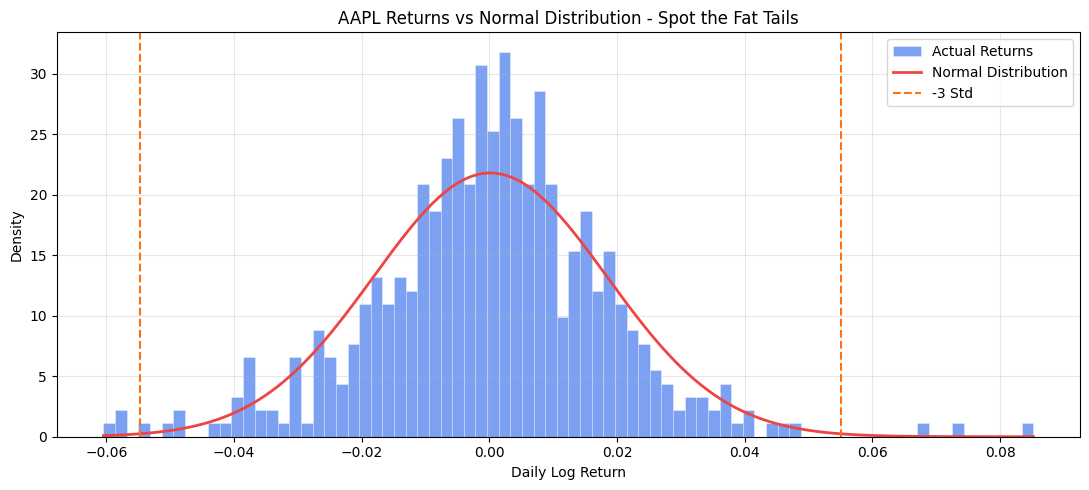

In [9]:
from scipy.stats import norm

fig, ax=plt.subplots(figsize=(11, 5))

ax.hist(log_returns, bins=80, density=True,
        color='#2563eb', alpha=0.6,
        edgecolor='white', lw=0.4 , label='Actual Returns')
x=np.linspace(log_returns.min(), log_returns.max(), 300)
ax.plot(x, norm.pdf(x, mean, std),
        color='#ef4444', lw=2, label='Normal Distribution')
            
ax.axvline(mean -3*std, color='#f97316', lw=1.5,
           linestyle='--', label='-3 Std')
ax.axvline(mean +3*std, color='#f97316', lw=1.5,
           linestyle='--')

ax.set_title('AAPL Returns vs Normal Distribution - Spot the Fat Tails')
ax.set_xlabel('Daily Log Return')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
        

In [11]:
threshold =3 *std
actual_tail = (np.abs(log_returns) >threshold).sum()
normal_pred = 2 * (1- norm.cdf(3)) * len(log_returns)

print(f"Total trading days  :{len(log_returns)}")
print(f"Days beyond  ±3 std   :{actual_tail} actual")
print(f"Days beyond  ±3 std   :{normal_pred:1f} predicted by normal")
print(f"Ratio actual/predicted  :{actual_tail/normal_pred:.1f}x more than expected")

Total trading days  :500
Days beyond  ±3 std   :6 actual
Days beyond  ±3 std   :1.349898 predicted by normal
Ratio actual/predicted  :4.4x more than expected


In [12]:
from scipy.stats import shapiro, jarque_bera

stat_sw, p_sw = shapiro(log_returns)
stat_jb, p_jb= jarque_bera(log_returns)

print("NORMALITY TESTS")
print("=" * 45)
print(f"Shapiro-Wilk  stat={stat_sw: .4f} p={p_sw: .6f}")
print(f"Jarque-Bera   stat={stat_jb: .4f} p={p_jb: .6f}")
print("=" * 45)
print(f"\nColnclusion: Returns are {'NOT' if p_sw<0.05 else ''}normally distibuted")
print(f"(p < 0.05 means we reject normality)")

NORMALITY TESTS
Shapiro-Wilk  stat= 0.9790 p= 0.000001
Jarque-Bera   stat= 71.1366 p= 0.000000

Colnclusion: Returns are NOTnormally distibuted
(p < 0.05 means we reject normality)


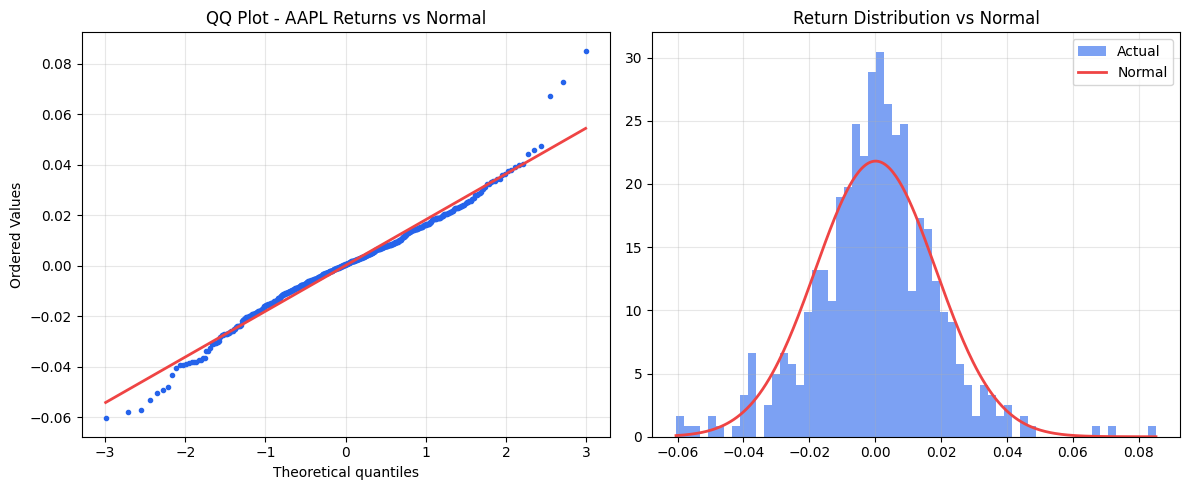

In [13]:
from scipy.stats import probplot

fi, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

probplot(log_returns, dist="norm", plot=ax1)
ax1.set_title("QQ Plot - AAPL Returns vs Normal")
ax1.get_lines()[0].set(color='#2563eb', markersize=3)
ax1.get_lines()[1].set(color='#ef4444', lw=2)
ax1.grid(True, alpha=0.3)

x= np.linspace(log_returns.min(), log_returns.max(), 300)
ax2.hist(log_returns, bins=60, density=True,
         color='#2563eb', alpha=0.6, label='Actual')
ax2.plot(x, norm.pdf(x, mean, std),
         color='#ef4444', lw=2, label='Normal')
ax2.set_title("Return Distribution vs Normal")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
tickers = ["AAPL", "SPY", "BTC-USD"]
results = {}

for t in tickers:
    d = yf.download(t, start="2022-01-01",
                    end="2024-01-01", auto_adjust=True)
    d.columns = d.columns.get_level_values(0)
    r = np.log(d["Close"] / d["Close"].shift(1)).dropna()
    results[t] = {
        "skew": r.skew(),
        "kurt": r.kurt(),
        "std" : r.std() * np.sqrt(252)
    }

print(f"{'Asset':<12} {'Ann Vol':>10} {'Skewness':>10} {'Ex. Kurt':>10}")
print("-" * 44)
for t, v in results.items():
    print(f"{t:<12} {v['std']:>10.2%} {v['skew']:>10.3f} {v['kurt']:>10.3f}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Asset           Ann Vol   Skewness   Ex. Kurt
--------------------------------------------
AAPL             29.04%      0.066      1.874
SPY              19.54%     -0.128      1.273
BTC-USD          45.67%     -0.411      5.596


[*********************100%***********************]  1 of 1 completed



  AAPL DISTRIBUTION ANALYSIS
  Skewness         :   0.0656
  Excess Kurtosis  :   1.8739
  Shapiro p-value  : 0.000001
  Jarque-Bera p    : 0.000000
  Tail events (3σ) : 6 actual vs 1.3 normal
  Fat tail ratio   : 4.4x more extreme than normal
  Normal dist?     : NO


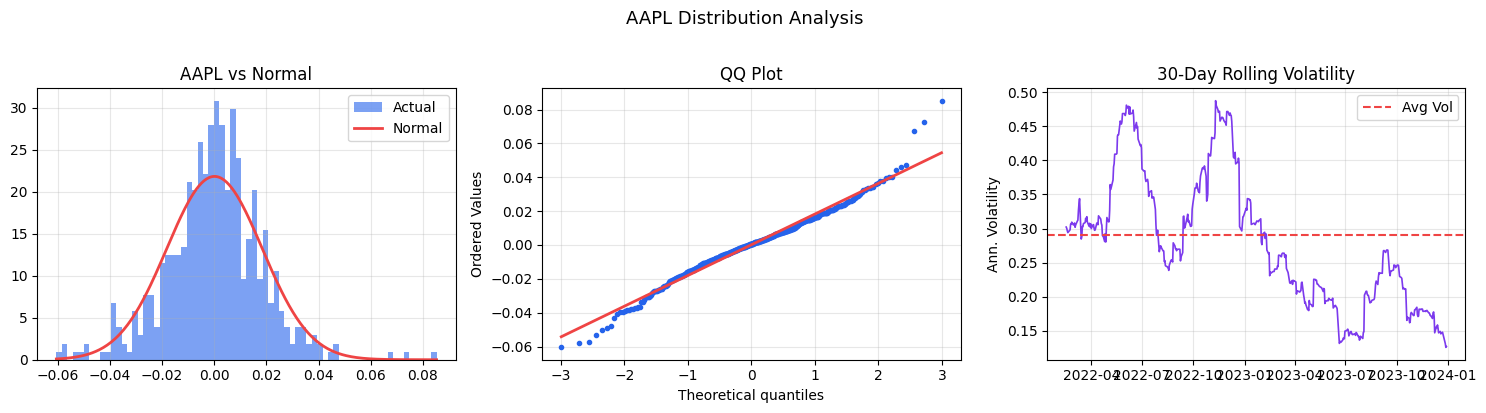

[*********************100%***********************]  1 of 1 completed



  SPY DISTRIBUTION ANALYSIS
  Skewness         :  -0.1280
  Excess Kurtosis  :   1.2726
  Shapiro p-value  : 0.000128
  Jarque-Bera p    : 0.000000
  Tail events (3σ) : 5 actual vs 1.3 normal
  Fat tail ratio   : 3.7x more extreme than normal
  Normal dist?     : NO


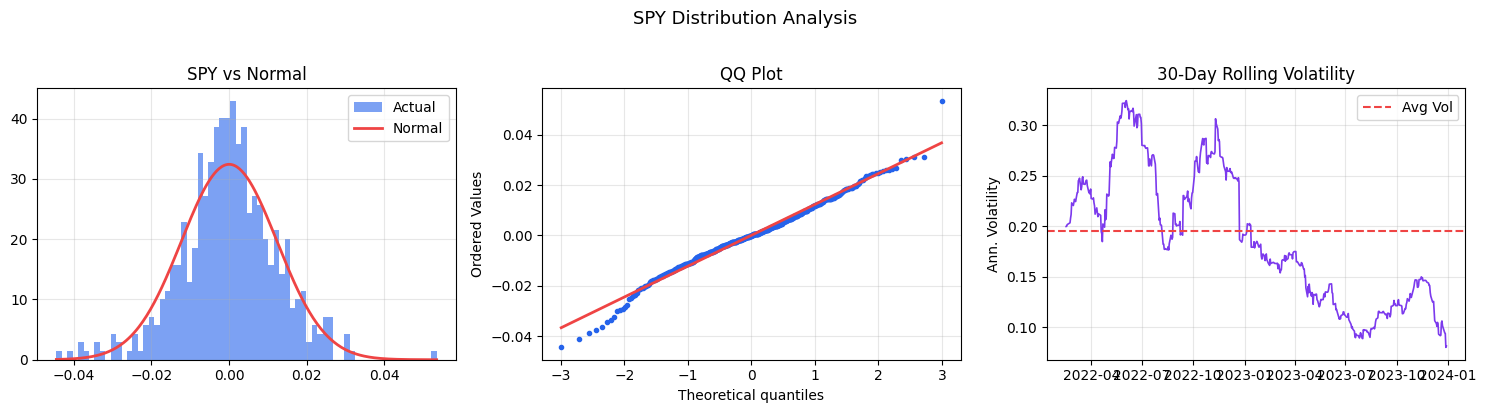

[*********************100%***********************]  1 of 1 completed



  BTC-USD DISTRIBUTION ANALYSIS
  Skewness         :  -0.4106
  Excess Kurtosis  :   5.5965
  Shapiro p-value  : 0.000000
  Jarque-Bera p    : 0.000000
  Tail events (3σ) : 16 actual vs 2.0 normal
  Fat tail ratio   : 8.1x more extreme than normal
  Normal dist?     : NO


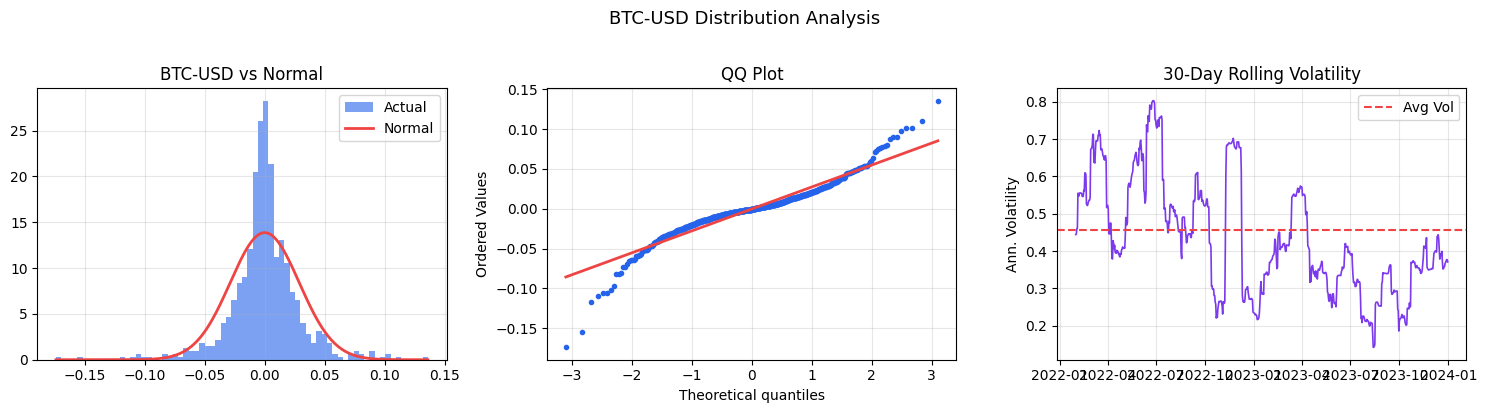

In [20]:
from scipy.stats import norm, shapiro, jarque_bera, probplot

def distribution_analysis(ticker, start="2022-01-01", end="2024-01-01"):
    """
    Full statistical distribution analysis for any ticker.
    Shows 3-panel diagnostic chart and prints stats summary.
    """
    # --- Data ---
    df = yf.download(ticker, start=start, end=end, auto_adjust=True)
    df.columns = df.columns.get_level_values(0)
    r = np.log(df["Close"] / df["Close"].shift(1)).dropna()
    mu, sigma = r.mean(), r.std()

    # --- Stats ---
    _, p_sw = shapiro(r)
    _, p_jb = jarque_bera(r)
    tail_actual = (np.abs(r) > 3*sigma).sum()
    tail_normal = 2 * (1 - norm.cdf(3)) * len(r)

    # --- Print ---
    print(f"\n{'='*45}")
    print(f"  {ticker} DISTRIBUTION ANALYSIS")
    print(f"{'='*45}")
    print(f"  Skewness         : {r.skew():>8.4f}")
    print(f"  Excess Kurtosis  : {r.kurt():>8.4f}")
    print(f"  Shapiro p-value  : {p_sw:>8.6f}")
    print(f"  Jarque-Bera p    : {p_jb:>8.6f}")
    print(f"  Tail events (3σ) : {tail_actual} actual vs {tail_normal:.1f} normal")
    print(f"  Fat tail ratio   : {tail_actual/tail_normal:.1f}x more extreme than normal")
    print(f"  Normal dist?     : {'NO' if p_sw < 0.05 else 'YES'}")

    # --- 3-panel chart ---
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

    # Panel 1: histogram vs normal
    x = np.linspace(r.min(), r.max(), 300)
    ax1.hist(r, bins=70, density=True, color='#2563eb',
             alpha=0.6, label='Actual')
    ax1.plot(x, norm.pdf(x, mu, sigma), '#ef4444', lw=2, label='Normal')
    ax1.set_title(f'{ticker} vs Normal')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Panel 2: QQ plot
    probplot(r, dist="norm", plot=ax2)
    ax2.set_title("QQ Plot")
    ax2.get_lines()[0].set(color='#2563eb', markersize=3)
    ax2.get_lines()[1].set(color='#ef4444', lw=2)
    ax2.grid(True, alpha=0.3)

    # Panel 3: rolling volatility
    rolling_vol = r.rolling(30).std() * np.sqrt(252)
    ax3.plot(rolling_vol, color='#7c3aed', lw=1.2)
    ax3.axhline(sigma * np.sqrt(252), color='#ef4444',
                lw=1.5, linestyle='--', label='Avg Vol')
    ax3.set_title("30-Day Rolling Volatility")
    ax3.set_ylabel("Ann. Volatility")
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.suptitle(f"{ticker} Distribution Analysis", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

# Test on all 3 assets
distribution_analysis("AAPL")
distribution_analysis("SPY")
distribution_analysis("BTC-USD")

UnicodeEncodeError: 'charmap' codec can't encode character '\u03c3' in position 1117: character maps to <undefined>